# Person 2 — Antibiotic pharmacodynamics parameter sweep
## $\gamma$, $h_a$, and initial antibiotic dose $a_0$

This notebook follows the organization and endpoint conventions used in the BME574 project repository and applies them to the **antibiotic pharmacodynamics** workstream.

These three parameters are analyzed together because they determine the antibiotic-induced lysis term

$$
l = \gamma\frac{a^{h_a}}{1+a^{h_a}}g.
$$

- $\gamma$: maximum lysis coefficient — **how hard the antibiotic can kill**.
- $h_a$: antibiotic Hill coefficient — **how steeply killing turns on with concentration**.
- $a_0$: initial antibiotic concentration — **where treatment starts on the dose-response curve**.

The main question is whether these parameters primarily change **population killing and recovery**, **final community composition**, or both.

## Sweep setup

The included results use a structured **15 × 15 × 15 grid = 3,375 simulations**:

$$
1.1 \le \gamma \le 1.4,
\qquad
1 \le h_a \le 5,
\qquad
1 \le a_0 \le 100.
$$

$\gamma$ and $h_a$ use the Supplementary Information randomized ranges. $a_0$ is a treatment variable rather than a randomized strain parameter, so it is sampled logarithmically over the paper's dose range.

All other parameters are held at the Supplementary Information base values:

$$
\alpha=0.95,\; \beta_{\min}=0.9,\; c=0.7,\; h_i=2,\;
\kappa_b=0.35,\; d_a=0.02,\; d_b=1,\; \xi=0.8,\; \phi_{\max}=1.
$$

The inhibitor is fixed at $i=10$ so that this sweep isolates the antibiotic side of the model. Initial conditions are

$$
n_s(0)=n_r(0)=0.2,\qquad s(0)=4,\qquad b(0)=0.
$$

The simulation horizon is $\tau=400$. In the included run, every parameter combination reached the numerical steady-state criterion before the end of this horizon.

> Set `N_PER_AXIS = 21` if you want the same 21 × 21 × 21 resolution used by the earlier project report. The included 15-point grid was used to keep the full three-dimensional sweep practical while preserving the same analysis structure.

In [1]:
from dataclasses import dataclass, replace
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import display

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

DATA_FILE = Path("person2_gamma_ha_a0_grid.csv")
PAPER_DOSE_FILE = Path("person2_gamma_ha_paperdose_2p15.csv")
FORCE_RERUN = False
N_PER_AXIS = 15
I_DOSE = 10.0
T_END = 400.0
N_TIME = 121


## Model implementation

The base model has five dynamic variables:

$$
\frac{dn_s}{d\tau}=(g-l)n_s,
$$

$$
\frac{dn_r}{d\tau}=(\alpha g-\beta l)n_r,
$$

$$
\frac{ds}{d\tau}=(\xi l-g)n_s+(\xi\beta l-\alpha g)n_r,
$$

$$
\frac{da}{d\tau}=-\kappa_bba-\phi n_ra-d_aa,
$$

$$
\frac{db}{d\tau}=\beta ln_r-d_b\iota b.
$$

The closure relations are

$$
g=\frac{s}{1+s},\qquad
l=\gamma\frac{a^{h_a}}{1+a^{h_a}}g,
$$

$$
\iota=\frac{i^{h_i}}{1+i^{h_i}},\qquad
\beta=\beta_{\min}+c(1-\beta_{\min})\iota,
$$

$$
\phi=\phi_{\max}(1-c\iota).
$$

For numerical stability through deep antibiotic bottlenecks, the solver integrates $\ln n_s$ and $\ln n_r$ rather than the raw population densities. This is algebraically equivalent to the original population equations.

In [2]:
@dataclass
class Params:
    alpha: float = 0.95
    beta_min: float = 0.90
    c: float = 0.70
    gamma: float = 1.38
    h_a: float = 3.0
    h_i: float = 2.0
    kappa_b: float = 0.35
    d_a: float = 0.02
    d_b: float = 1.0
    xi: float = 0.80
    phi_max: float = 1.0

BASE = Params()

def hill(x, h):
    x = np.maximum(x, 0.0)
    xh = np.power(x, h)
    return xh / (1.0 + xh)

def rhs_logspace(t, y, p, i_dose):
    ln_ns, ln_nr, s, a, b = y
    ns, nr = np.exp(ln_ns), np.exp(ln_nr)
    g = s / (1.0 + s)
    l = p.gamma * hill(a, p.h_a) * g
    iota = hill(i_dose, p.h_i)
    beta = p.beta_min + p.c * (1.0 - p.beta_min) * iota
    phi = p.phi_max * (1.0 - p.c * iota)

    dln_ns = g - l
    dln_nr = p.alpha * g - beta * l
    ds = (p.xi*l - g)*ns + (p.xi*beta*l - p.alpha*g)*nr
    da = -p.kappa_b*b*a - phi*nr*a - p.d_a*a
    db = beta*l*nr - p.d_b*iota*b
    return np.array([dln_ns, dln_nr, ds, da, db])

def simulate(p, a0, i_dose=I_DOSE, t_end=T_END, n_time=N_TIME):
    y0 = np.array([np.log(0.2), np.log(0.2), 4.0, float(a0), 0.0])
    t_eval = np.linspace(0, t_end, n_time)
    sol = solve_ivp(
        rhs_logspace, (0, t_end), y0,
        args=(p, i_dose), t_eval=t_eval,
        method="LSODA", rtol=1e-8, atol=1e-10,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    sol.ns = np.exp(sol.y[0])
    sol.nr = np.exp(sol.y[1])
    sol.s, sol.a, sol.b = sol.y[2], sol.y[3], sol.y[4]
    return sol

def shannon(ns, nr):
    total = ns + nr
    ps = np.divide(ns, total, out=np.zeros_like(ns), where=total>0)
    pr = np.divide(nr, total, out=np.zeros_like(nr), where=total>0)
    hs = np.where(ps>0, -ps*np.log(ps), 0.0)
    hr = np.where(pr>0, -pr*np.log(pr), 0.0)
    return hs + hr


## Endpoint definitions

The notebook uses the same types of endpoints as the shared project analyses:

- **Final resistant fraction**: $f_R=n_r/(n_s+n_r)$.
- **Shannon diversity** of the two populations.
- **Final total live population**: $n_s+n_r$.
- **Time to steady state**: both populations' absolute per-capita growth rates remain below $10^{-3}$ for the remainder of the run.
- **Sensitive recovery time**: first time $S$ returns to at least 90% of its own final level after dipping below that level.
- **Peak population loss**: largest fractional drop of total population below its starting value.
- **Initial lysis strength**: $l(0)$ and $l(0)/g(0)$.

The sweep also records the minimum populations and the time at which antibiotic falls below its dimensionless half-maximal scale $a=1$.

In [3]:
TOL_SS = 1e-3
RECOVERY_FRACTION = 0.9

# Drug-free S reference for the viability flag.
_ref = simulate(BASE, a0=0.0, i_dose=0.0)
NS_DRUG_FREE = float(_ref.ns[-1])

def compute_endpoints(gamma, h_a, a0):
    p = replace(BASE, gamma=float(gamma), h_a=float(h_a))
    sol = simulate(p, a0=float(a0))
    ns, nr, t = sol.ns, sol.nr, sol.t
    total = ns + nr
    nsf, nrf = ns[-1], nr[-1]
    totalf = total[-1]
    fR = nrf / totalf
    H = shannon(ns, nr)
    ib = int(np.argmin(total))

    # Vectorized steady-state calculation using population per-capita rates.
    g = sol.s / (1.0 + sol.s)
    l = p.gamma * hill(sol.a, p.h_a) * g
    iota = hill(I_DOSE, p.h_i)
    beta = p.beta_min + p.c*(1-p.beta_min)*iota
    rate = np.maximum(np.abs(g-l), np.abs(p.alpha*g-beta*l))
    below = rate < TOL_SS
    idx = len(t)-1
    while idx > 0 and below[idx-1]:
        idx -= 1
    t_ss = float(t[idx])
    converged = bool(below[-1] and (t[-1]-t_ss) >= 0.1*T_END)
    if not converged:
        t_ss = T_END

    # S recovery relative to its eventual value.
    recovery_line = RECOVERY_FRACTION * nsf
    dip = np.flatnonzero(ns < recovery_line)
    if len(dip) == 0:
        t_rec = 0.0
    else:
        start = int(dip[0])
        back = np.flatnonzero(ns[start:] >= recovery_line)
        t_rec = float(t[start + back[0]]) if len(back) else np.nan

    g0 = 4.0/5.0
    H0 = float(hill(a0, h_a))
    l_over_g0 = float(gamma * H0)
    l0 = float(l_over_g0 * g0)
    below1 = np.flatnonzero(sol.a <= 1.0)
    t_a_below_1 = float(t[below1[0]]) if len(below1) else np.nan

    return {
        "gamma": float(gamma), "h_a": float(h_a), "a0": float(a0),
        "i_dose": I_DOSE,
        "initial_hill": H0,
        "initial_lysis_ratio_l_over_g": l_over_g0,
        "initial_lysis_l0": l0,
        "f_R_final": float(fR),
        "total_final": float(totalf), "ns_final": float(nsf), "nr_final": float(nrf),
        "diversity_final": float(H[-1]), "diversity_min": float(H.min()),
        "diversity_at_bottleneck": float(H[ib]),
        "t_steady_state": t_ss, "ss_converged": converged,
        "t_recovery_S": t_rec,
        "peak_loss_S": float((ns[0]-ns.min())/ns[0]),
        "peak_loss_total": float((total[0]-total.min())/total[0]),
        "min_total": float(total.min()), "min_ns": float(ns.min()), "min_nr": float(nr.min()),
        "t_bottleneck": float(t[ib]), "t_antibiotic_below_1": t_a_below_1,
        "sensitive_survives": bool(nsf >= 0.5*NS_DRUG_FREE),
        "resistant_eliminated_abs": bool(nrf < 1e-4),
        "log_R_over_S_change": float((sol.y[1,-1]-sol.y[0,-1])-(sol.y[1,0]-sol.y[0,0])),
    }


## Run or load the three-dimensional sweep

The downloaded bundle includes the precomputed CSV. Set `FORCE_RERUN = True` to recompute the full grid from the ODEs.

In [4]:
if DATA_FILE.exists() and not FORCE_RERUN:
    df = pd.read_csv(DATA_FILE)
    print(f"Loaded precomputed grid: {len(df):,} simulations")
else:
    gammas = np.linspace(1.1, 1.4, N_PER_AXIS)
    h_as = np.linspace(1.0, 5.0, N_PER_AXIS)
    a0s = np.geomspace(1.0, 100.0, N_PER_AXIS)
    rows = []
    total_jobs = len(gammas)*len(h_as)*len(a0s)
    for k, (gamma, h_a, a0) in enumerate(
        (x for x in ((g,h,a) for g in gammas for h in h_as for a in a0s)), start=1
    ):
        rows.append(compute_endpoints(gamma, h_a, a0))
        if k % 250 == 0 or k == total_jobs:
            print(f"{k:,}/{total_jobs:,} simulations complete")
    df = pd.DataFrame(rows).sort_values(["gamma","h_a","a0"]).reset_index(drop=True)
    df.to_csv(DATA_FILE, index=False)
    print(f"Saved {DATA_FILE}")

display(df.head())


Loaded precomputed grid: 3,375 simulations


,gamma,h_a,a0,i_dose,initial_hill,initial_lysis_ratio_l_over_g,initial_lysis_l0,f_R_final,log_R_over_S_change,total_final,ns_final,nr_final,diversity_final,diversity_min,diversity_at_bottleneck,t_steady_state,ss_converged,t_recovery_S,peak_loss_S,peak_loss_total,min_total,min_ns,min_nr,t_bottleneck,t_antibiotic_below_1,resistant_eliminated_abs,sensitive_survives
0,1.1,1.0,1.000000,10.0,0.500000,0.550000,0.440000,0.462070,-0.152011,4.010466,2.157349,1.853117,0.690267,0.690267,0.693147,10.000000,True,6.666667,0.0,0.0,0.4,0.2,0.2,0.0,0.000000,False,True
1,1.1,1.0,1.389495,10.0,0.581502,0.639652,0.511721,0.459715,-0.161489,3.913325,2.114309,1.799015,0.689898,0.689898,0.693147,10.000000,True,6.666667,0.0,0.0,0.4,0.2,0.2,0.0,3.333333,False,True
2,1.1,1.0,1.930698,10.0,0.658784,0.724663,0.579730,0.456721,-0.173551,3.803715,2.066479,1.737236,0.689396,0.689396,0.693147,10.000000,True,10.000000,0.0,0.0,0.4,0.2,0.2,0.0,6.666667,False,True
3,1.1,1.0,2.682696,10.0,0.728460,0.801306,0.641045,0.452958,-0.188726,3.683341,2.014942,1.668399,0.688715,0.688715,0.693147,13.333333,True,10.000000,0.0,0.0,0.4,0.2,0.2,0.0,6.666667,False,True
4,1.1,1.0,3.727594,10.0,0.788476,0.867323,0.693859,0.448275,-0.207644,3.554185,1.960934,1.593251,0.687787,0.687787,0.693147,13.333333,True,10.000000,0.0,0.0,0.4,0.2,0.2,0.0,10.000000,False,True


# 1. Endpoint analysis

In [5]:
summary = pd.DataFrame({
    "metric": [
        "final resistant fraction", "final total population", "Shannon diversity",
        "time to steady state", "S recovery time", "peak total population loss"
    ],
    "min": [df.f_R_final.min(), df.total_final.min(), df.diversity_final.min(),
            df.t_steady_state.min(), df.t_recovery_S.min(), df.peak_loss_total.min()],
    "median": [df.f_R_final.median(), df.total_final.median(), df.diversity_final.median(),
               df.t_steady_state.median(), df.t_recovery_S.median(), df.peak_loss_total.median()],
    "max": [df.f_R_final.max(), df.total_final.max(), df.diversity_final.max(),
            df.t_steady_state.max(), df.t_recovery_S.max(), df.peak_loss_total.max()],
})
display(summary.round(4))
print(f"Steady-state convergence: {df.ss_converged.mean():.1%}")
print(f"Sensitive viable at the end: {df.sensitive_survives.mean():.1%}")
print(f"Resistant population below 1e-4 at the end: {df.resistant_eliminated_abs.mean():.1%}")
print(f"Runs with final f_R > 0.5: {(df.f_R_final > 0.5).mean():.1%}")


,metric,min,median,max
0,final resistant fraction,0.0090,0.2090,0.4659
1,final total population,2.1939,3.8361,4.2860
2,Shannon diversity,0.0514,0.5127,0.6908
3,time to steady state,6.6667,86.6667,300.0000
4,S recovery time,6.6667,83.3333,300.0000
5,peak total population loss,0.0000,0.9941,1.0000


Steady-state convergence: 100.0%
Sensitive viable at the end: 100.0%
Resistant population below 1e-4 at the end: 0.0%
Runs with final f_R > 0.5: 0.0%


In [6]:
def heatmap_slices(outcome, label, hs=(1,3,5), vmin=None, vmax=None, cmap="viridis"):
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.7), sharey=True, constrained_layout=True)
    if vmin is None: vmin = df[outcome].min()
    if vmax is None: vmax = df[outcome].max()
    m = None
    for ax, h in zip(axes, hs):
        d = df[np.isclose(df.h_a, h)]
        tab = d.pivot(index="gamma", columns="a0", values=outcome).sort_index()
        x = np.log10(tab.columns.to_numpy(float))
        y = tab.index.to_numpy(float)
        m = ax.pcolormesh(x, y, tab.to_numpy(), shading="nearest", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(fr"$h_a={h:g}$")
        ax.set_xlabel(r"$a_0$ (log scale)")
        ax.set_xticks([0, 0.5, 1, 1.5, 2])
        ax.set_xticklabels(["1", "3.2", "10", "32", "100"])
    axes[0].set_ylabel(r"$\gamma$")
    cb = fig.colorbar(m, ax=axes, pad=0.02)
    cb.set_label(label)
    return fig


## 1.1 Diversity at steady state

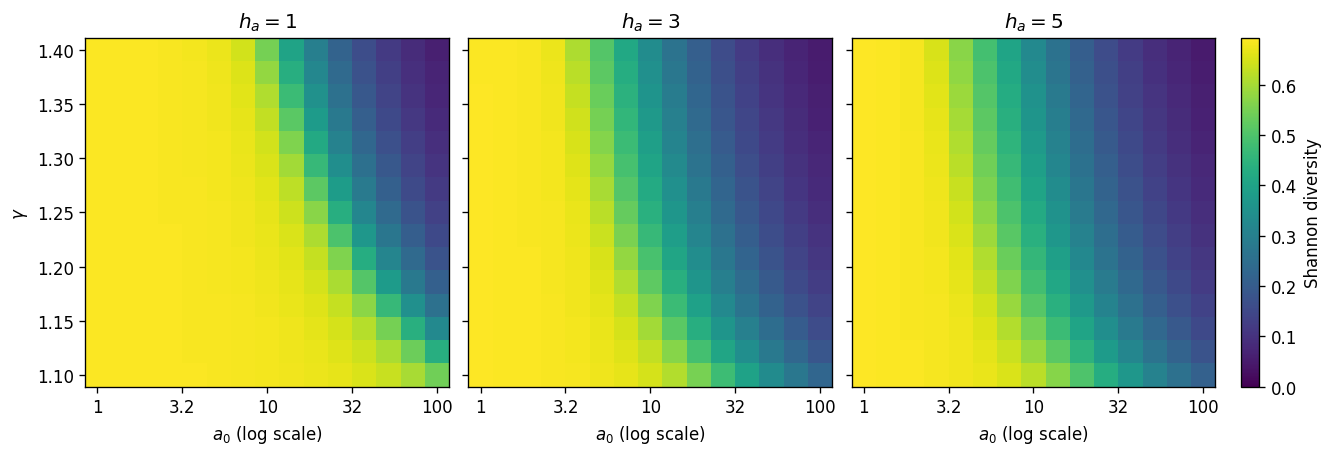

In [7]:
heatmap_slices("diversity_final", "Shannon diversity", vmin=0, vmax=np.log(2))
plt.show()


With only two populations, diversity is largest near $f_R=0.5$ and falls as one population dominates. In this sweep, increasing antibiotic intensity shifts the system toward susceptible dominance, so diversity falls together with $f_R$.

## 1.2 Time to steady state

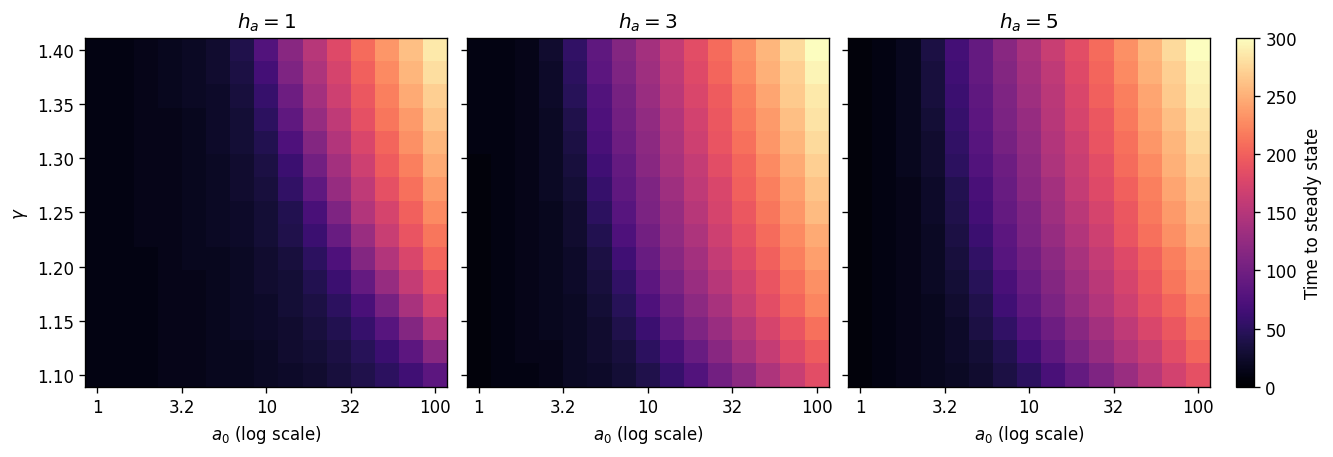

In [8]:
heatmap_slices("t_steady_state", "Time to steady state", vmin=0, vmax=300, cmap="magma")
plt.show()


All included simulations converged within the 400-time-unit horizon. High antibiotic doses create long crash-and-recovery trajectories, so dose has a much stronger effect on settling time than either Hill steepness or the relatively narrow allowed range of maximum lysis coefficient.

## 1.3 Final resistant fraction

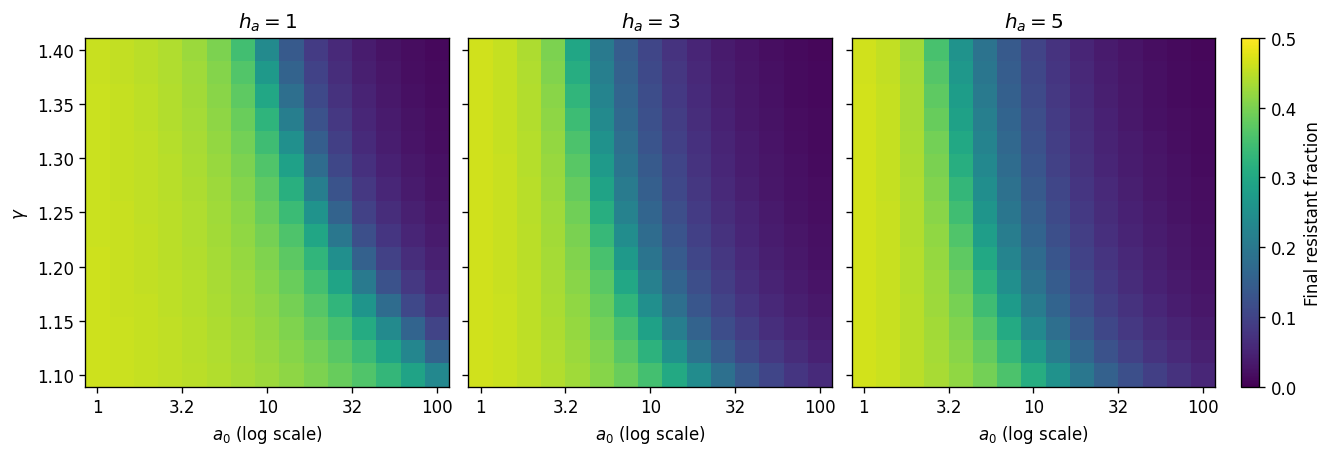

In [9]:
heatmap_slices("f_R_final", "Final resistant fraction", vmin=0, vmax=0.5)
plt.show()


In [10]:
print(f"Final f_R range: {df.f_R_final.min():.4f} to {df.f_R_final.max():.4f}")
print(f"Fraction of grid with f_R < 0.10: {(df.f_R_final < .10).mean():.1%}")
print(f"Fraction of grid with f_R < 0.05: {(df.f_R_final < .05).mean():.1%}")
print(f"Fraction of grid with f_R > 0.50: {(df.f_R_final > .50).mean():.1%}")


Final f_R range: 0.0090 to 0.4659
Fraction of grid with f_R < 0.10: 34.9%
Fraction of grid with f_R < 0.05: 20.8%
Fraction of grid with f_R > 0.50: 0.0%


For the fixed resistance parameters and strong inhibitor used here, **every point ends with a resistant fraction below the initial 0.5**. Thus $\gamma$, $h_a$, and $a_0$ change the *strength* of selection against resistance but do not reverse its direction in this particular slice of the full model.

# 2. How the three pharmacodynamic parameters act

## 2.1 Direct effect on the lysis function

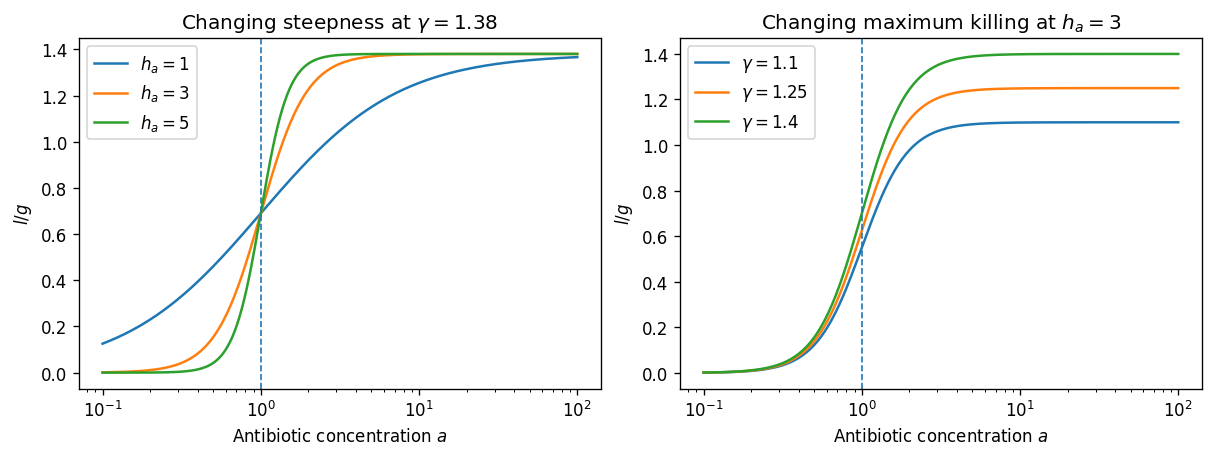

In [11]:
A = np.geomspace(0.1, 100, 400)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), constrained_layout=True)
for h in [1,3,5]:
    axes[0].semilogx(A, BASE.gamma*hill(A,h), label=fr"$h_a={h}$")
axes[0].axvline(1, ls="--", lw=1)
axes[0].set_xlabel("Antibiotic concentration $a$")
axes[0].set_ylabel(r"$l/g$")
axes[0].set_title(r"Changing steepness at $\gamma=1.38$")
axes[0].legend()

for gam in [1.1,1.25,1.4]:
    axes[1].semilogx(A, gam*hill(A,3), label=fr"$\gamma={gam:g}$")
axes[1].axvline(1, ls="--", lw=1)
axes[1].set_xlabel("Antibiotic concentration $a$")
axes[1].set_ylabel(r"$l/g$")
axes[1].set_title(r"Changing maximum killing at $h_a=3$")
axes[1].legend()
plt.show()


$h_a$ mainly changes the transition around the scaled dose $a\approx1$. Once $a\gg1$, the Hill term is near 1 for all $h_a$, so the curves converge toward $l/g\approx\gamma$. This explains why changing $h_a$ often has much less effect than changing the dose over two orders of magnitude.

## 2.2 Dose dominates final composition and the transient bottleneck

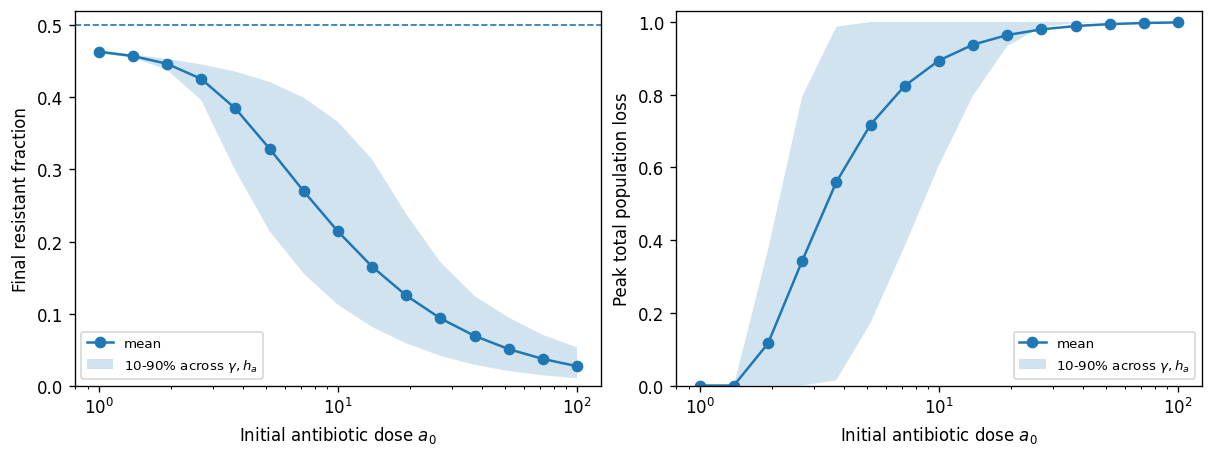

In [12]:
def band_by_a0(outcome):
    gr = df.groupby("a0")[outcome]
    x = np.array(sorted(df.a0.unique()))
    return x, gr.mean().reindex(x).to_numpy(), gr.quantile(.1).reindex(x).to_numpy(), gr.quantile(.9).reindex(x).to_numpy()

fig, axes = plt.subplots(1,2,figsize=(10,3.7),constrained_layout=True)
for ax, outcome, ylabel in [
    (axes[0], "f_R_final", "Final resistant fraction"),
    (axes[1], "peak_loss_total", "Peak total population loss"),
]:
    x, mean, lo, hi = band_by_a0(outcome)
    ax.semilogx(x, mean, marker="o", label="mean")
    ax.fill_between(x, lo, hi, alpha=.2, label=r"10-90% across $\gamma,h_a$")
    ax.set_xlabel(r"Initial antibiotic dose $a_0$")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
axes[0].axhline(.5, ls="--", lw=1)
axes[0].set_ylim(0,.52)
axes[1].set_ylim(0,1.03)
plt.show()


In [13]:
dose_summary = df.groupby("a0").agg(
    mean_fR=("f_R_final","mean"),
    mean_peak_loss=("peak_loss_total","mean"),
    mean_tSS=("t_steady_state","mean"),
    mean_recovery=("t_recovery_S","mean"),
    mean_total_final=("total_final","mean"),
)
display(dose_summary.round(4))


,mean_fR,mean_peak_loss,mean_tSS,mean_recovery,mean_total_final
a0,,,,,
1.000000,0.4635,0.0000,8.1630,6.6667,4.1686
1.389495,0.4575,0.0000,10.0000,8.5630,4.0309
1.930698,0.4467,0.1157,13.2741,11.3037,3.8828
2.682696,0.4258,0.3428,18.8593,16.9778,3.7483
3.727594,0.3847,0.5598,30.2519,28.4296,3.6611
5.179475,0.3290,0.7175,47.1111,45.3037,3.6216
7.196857,0.2699,0.8241,67.0667,65.2593,3.6114
10.000000,0.2141,0.8938,89.0222,87.1407,3.6196
13.894955,0.1652,0.9375,111.7333,110.0000,3.6394


# 3. Decoupling $\gamma$ and $h_a$ at the paper's $a_0=2.15$ dose

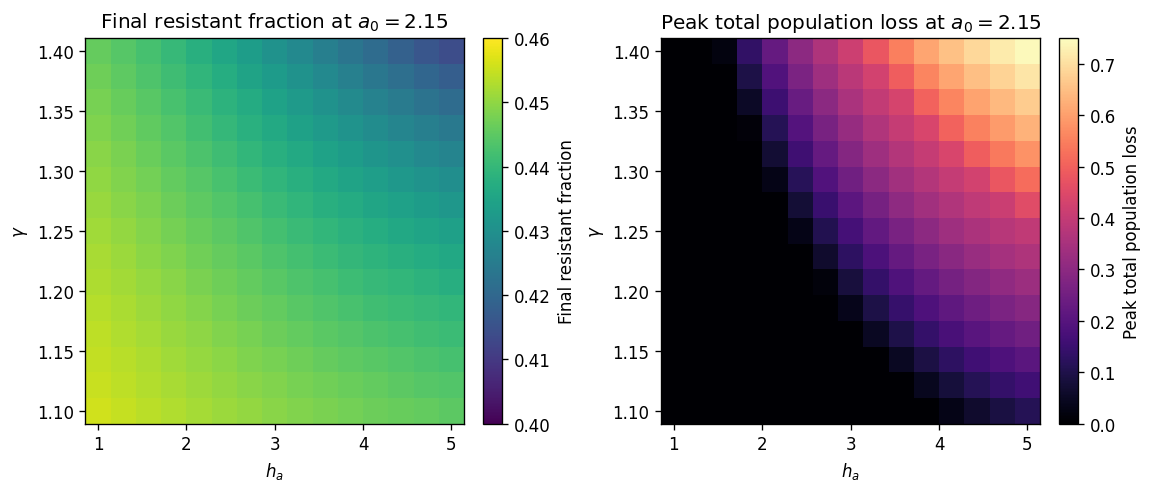

At a0=2.15, f_R spans 0.4139 to 0.4556.
At the same dose, peak total population loss spans 0.0% to 74.3%.


In [14]:
if PAPER_DOSE_FILE.exists() and not FORCE_RERUN:
    paper_dose = pd.read_csv(PAPER_DOSE_FILE)
else:
    rows = [compute_endpoints(g,h,2.15) for g in np.linspace(1.1,1.4,N_PER_AXIS) for h in np.linspace(1,5,N_PER_AXIS)]
    paper_dose = pd.DataFrame(rows)
    paper_dose.to_csv(PAPER_DOSE_FILE, index=False)

fig, axes = plt.subplots(1,2,figsize=(9.5,4),constrained_layout=True)
for ax, outcome, label, vmin, vmax, cmap in [
    (axes[0],"f_R_final","Final resistant fraction",.40,.46,"viridis"),
    (axes[1],"peak_loss_total","Peak total population loss",0,.75,"magma"),
]:
    tab = paper_dose.pivot(index="gamma",columns="h_a",values=outcome).sort_index()
    m = ax.pcolormesh(tab.columns,tab.index,tab.to_numpy(),shading="nearest",cmap=cmap,vmin=vmin,vmax=vmax)
    ax.set_xlabel(r"$h_a$")
    ax.set_ylabel(r"$\gamma$")
    ax.set_title(label + r" at $a_0=2.15$")
    fig.colorbar(m,ax=ax,label=label)
plt.show()

print(f"At a0=2.15, f_R spans {paper_dose.f_R_final.min():.4f} to {paper_dose.f_R_final.max():.4f}.")
print(f"At the same dose, peak total population loss spans {paper_dose.peak_loss_total.min():.1%} to {paper_dose.peak_loss_total.max():.1%}.")


This directly supports the observation that **changing $\gamma$ and $h_a$ can have a much larger effect on the depth of the transient crash than on the final S/R split at a fixed sub-lethal dose**. The composition endpoint is comparatively buffered because the same lysis term acts on both populations; their difference is mediated through the resistant lysis multiplier $\beta$.

# 4. Survival, recovery, and population loss

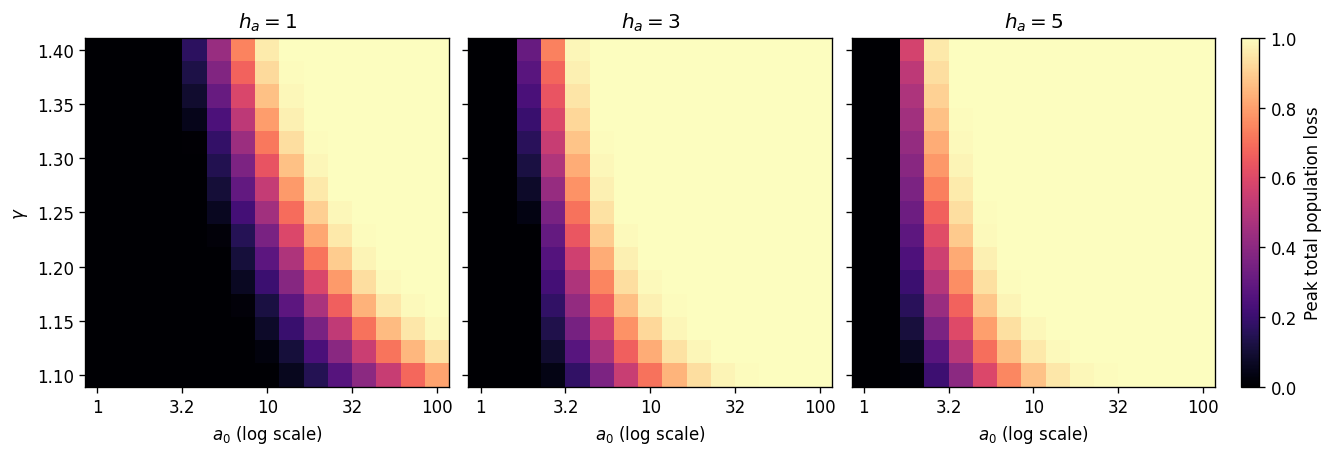

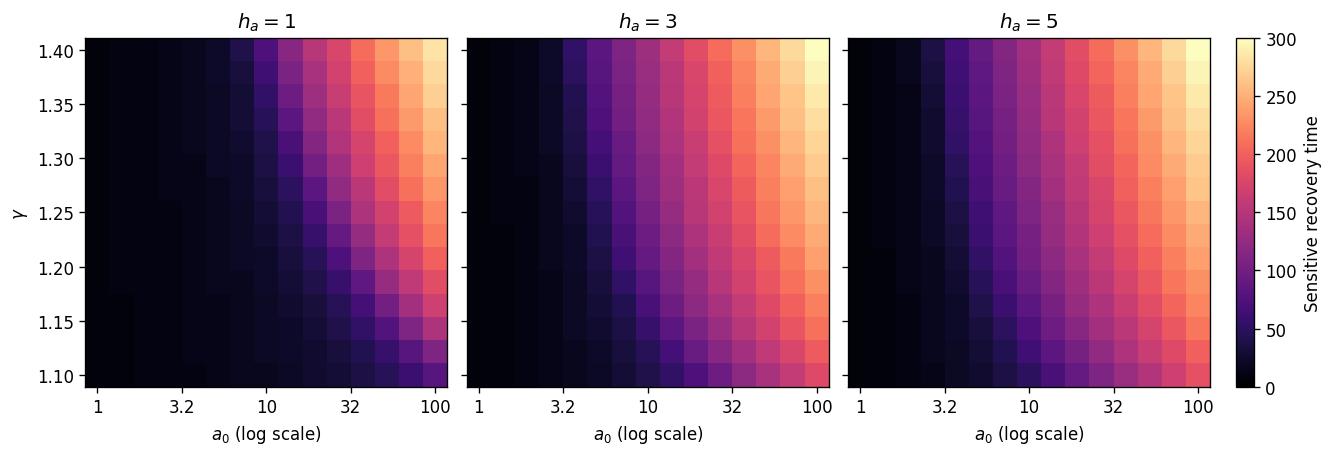

In [15]:
heatmap_slices("peak_loss_total", "Peak total population loss", vmin=0, vmax=1, cmap="magma")
plt.show()
heatmap_slices("t_recovery_S", "Sensitive recovery time", vmin=0, vmax=300, cmap="magma")
plt.show()


In [16]:
for threshold in [0.5,0.9,0.99,0.999]:
    print(f"Peak loss >= {threshold:.1%}: {(df.peak_loss_total >= threshold).mean():.1%} of the grid")
print(f"Final total population range: {df.total_final.min():.3f} to {df.total_final.max():.3f}")


Peak loss >= 50.0%: 69.2% of the grid
Peak loss >= 90.0%: 58.4% of the grid
Peak loss >= 99.0%: 51.1% of the grid
Peak loss >= 99.9%: 45.6% of the grid
Final total population range: 2.194 to 4.286


High doses often create an **extreme transient bottleneck**, but the deterministic single-dose model subsequently regrows because antibiotic is degraded/decays and nutrient remains available or is recycled. Thus a near-total temporary crash is not equivalent to final eradication.

# 5. Representative trajectories

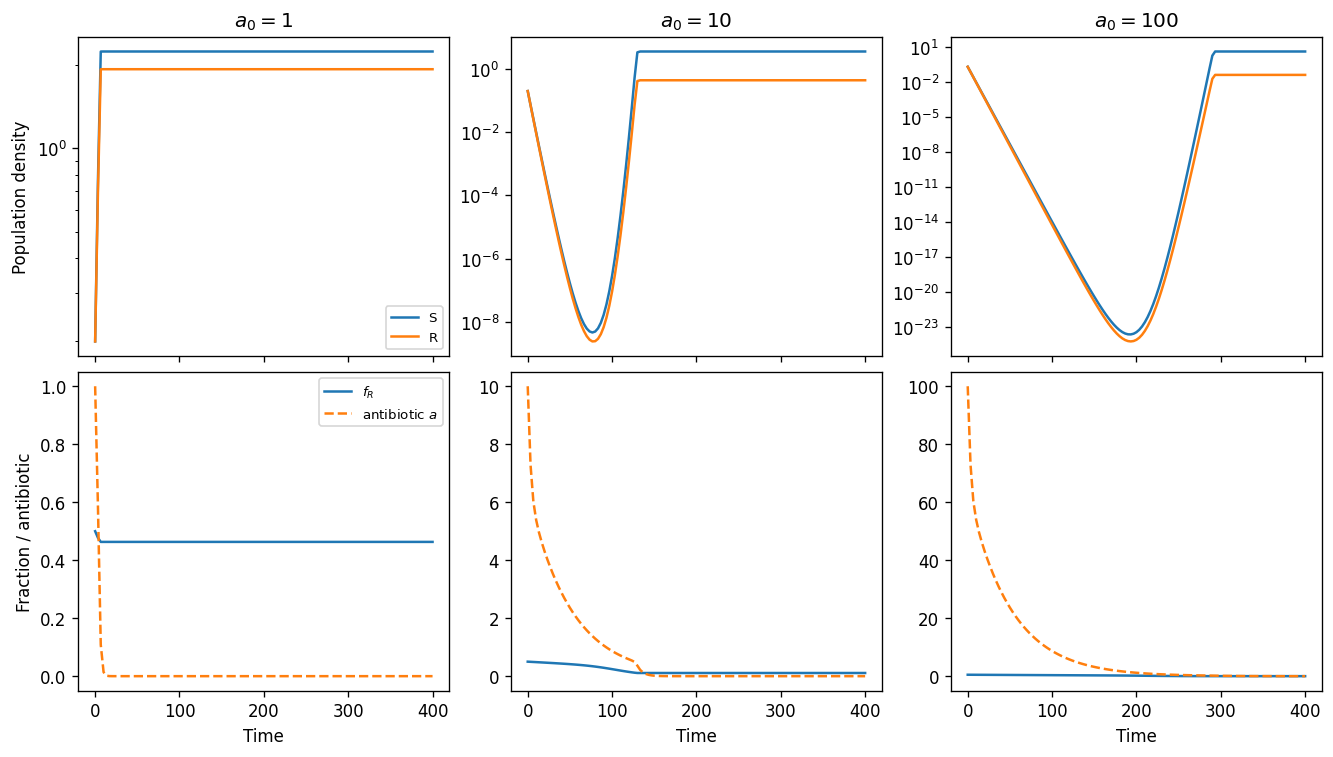

In [17]:
fig, axes = plt.subplots(2,3,figsize=(11,6.2),sharex="col",constrained_layout=True)
for col,a0 in enumerate([1,10,100]):
    sol = simulate(BASE,a0=a0)
    fr = sol.nr/(sol.ns+sol.nr)
    axes[0,col].semilogy(sol.t,sol.ns,label="S")
    axes[0,col].semilogy(sol.t,sol.nr,label="R")
    axes[0,col].set_title(fr"$a_0={a0}$")
    axes[1,col].plot(sol.t,fr,label="$f_R$")
    axes[1,col].plot(sol.t,sol.a,ls="--",label="antibiotic $a$")
    axes[1,col].set_xlabel("Time")
axes[0,0].set_ylabel("Population density")
axes[1,0].set_ylabel("Fraction / antibiotic")
axes[0,0].legend(fontsize=8)
axes[1,0].legend(fontsize=8)
plt.show()


# 6. Quantitative sensitivity summary

In [18]:
rows=[]
for p in ["gamma","h_a","a0"]:
    marginal = df.groupby(p).f_R_final.mean()
    rows.append({
        "parameter":p,
        "range of marginal mean f_R":marginal.max()-marginal.min(),
        "Spearman with final f_R":df[[p,"f_R_final"]].corr(method="spearman").iloc[0,1],
        "Spearman with peak loss":df[[p,"peak_loss_total"]].corr(method="spearman").iloc[0,1],
        "Spearman with time to SS":df[[p,"t_steady_state"]].corr(method="spearman").iloc[0,1],
    })
sensitivity = pd.DataFrame(rows)
display(sensitivity.round(3))


,parameter,range of marginal mean f_R,Spearman with final f_R,Spearman with peak loss,Spearman with time to SS
0,gamma,0.123,-0.228,0.334,0.217
1,h_a,0.092,-0.113,0.222,0.104
2,a0,0.437,-0.952,0.875,0.954


## Main findings from the included sweep

1. **Dose $a_0$ is the dominant control parameter.** Across the full range, its Spearman association with final resistant fraction is about $-0.95$, much stronger than $\gamma$ or $h_a$.
2. **Higher $\gamma$ and higher $h_a$ strengthen killing when $a>1$, but they do not independently create a new selection regime here.** With the fixed strong inhibitor and baseline resistance parameters, all simulations finish with $f_R<0.5$.
3. **At the paper's $a_0=2.15$ dose, final composition changes only modestly across $\gamma$ and $h_a$** ($f_R\approx0.414$ to $0.456$), even though peak total population loss ranges from essentially 0 to about 74%.
4. **Higher dose produces much deeper crashes and much longer recovery.** More than half of the full grid experiences at least 99% transient loss of total population.
5. **Deep killing is not the same as eradication in this single-dose deterministic model.** All runs end with viable S, none end with $n_R<10^{-4}$, and final total population remains substantial after regrowth.
6. **Mechanistically, $h_a$ is most influential near the transition dose $a\sim1$.** At high $a$, the Hill function saturates, so $h_a$ becomes much less important and $l/g$ approaches $\gamma$.

## Interpretation

The sweep supports a useful separation between **pharmacodynamic killing** and **evolutionary selection**. $\gamma$, $h_a$, and $a_0$ strongly determine how deep and how long the antibiotic-induced crash is. However, the final resistant-versus-susceptible split also depends on the parameters that differentiate the two populations — especially $\alpha$, $\beta_{\min}$, and $c$.

This is why changing lysis strength can drastically change total biomass loss without producing an equally dramatic change in final composition at a fixed moderate dose.